In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from joblib import Parallel, delayed, cpu_count

## Exercise 1: k-means/k-means++

In [2]:
# read dataset and visualize
data = np.loadtxt("data/s3.txt", dtype='int64')

### Implementing simple k-means

In [3]:
# functions for k-means
def update_assigns(data, centroids):
    return np.argmin(np.linalg.norm(np.tile(centroids, \
            (data.shape[0],1,1)) - data.reshape((data.shape[0],1,data.shape[1])), axis=2),axis=1).astype('int32')

def update_centroids(data, assigns, centroids):
    new_centroids = np.ndarray(shape=(centroids.shape[0], data.shape[1]), dtype='float64')
    for i in range(centroids.shape[0]):
        block = data[assigns==i]
        new_centroids[i] = np.mean(block, axis=0) if block.shape[0]!=0 else centroids[i]
    return new_centroids

def compute_loss(data, assigns, centroids):
    get_centroid = lambda n: centroids[n]
    return np.sum(np.square(data-get_centroid(assigns)))
  
def _kmeans(data, n_clusters):
    centroids = data[np.random.randint(0, data.shape[0], (n_clusters,))]                      # random centroids
    assigns = np.zeros(shape=(data.shape[0],))                                                # init assigns vector
    changed = True; rep=0
    while(changed and rep < 100): 
        new_assigns = update_assigns(data, centroids)                                         # get updated assigns
        changed = True if (new_assigns != assigns).any() else False                           # check if changed
        centroids = update_centroids(data, new_assigns, centroids) if changed else centroids  # update centroids
        assigns = new_assigns if changed else assigns                                         # update assigns 
        rep += 1
    loss = compute_loss(data, assigns, centroids)                                             # compute loss
    return centroids, assigns, loss

In [4]:
# function to run multiple jobs in parallel and return best
def kmeans(data, n_clusters=15, reps=10):  
    _results = Parallel(n_jobs=-1)(delayed(_kmeans)(data, n_clusters) for i in range(reps))
    _losses = [_results[i][2] for i in range(reps)]
    _avg = np.mean(_losses); 
    _best = _results[np.argmin(_losses)]
    return _best[0], _best[1], _best[2], _avg

In [5]:
# function to plot colorful clusters
def plot_clusters(data, assigns, centroids):
    for i in range(centroids.shape[0]):
        cluster = data[assigns==i]
        plt.scatter(cluster[:,0], cluster[:,1], s=4)  
    plt.scatter(centroids[:,0], centroids[:,1], s=12, c='k')

CPU times: user 479 ms, sys: 116 ms, total: 595 ms
Wall time: 2.78 s
Avg loss: 19721253117946.324
Min loss: 16889603913707.928


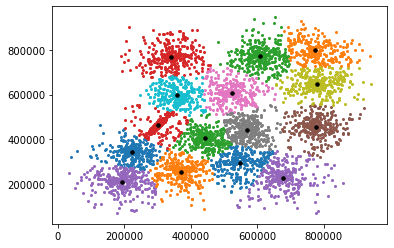

In [6]:
%time centroids, assigns, min_loss, avg_loss = kmeans(data, reps=100)
print(f"Avg loss: {avg_loss}")
print(f"Min loss: {min_loss}")
plot_clusters(data, assigns, centroids)

### Implementing k-means++

In [7]:
# functions for kmpp initialization
def compute_probs(data, centroids):
    square_diffs = np.min(np.sum(np.square(np.tile(centroids, \
                    (data.shape[0],1,1)) - data.reshape((data.shape[0],1,data.shape[1]))), axis=2), axis=1)
    return square_diffs / np.sum(square_diffs)
    
def kmpp_init(data, n_clusters=15):
    kmpp_centroids = np.ndarray(shape=(1,), dtype='int64')
    kmpp_centroids = data[np.random.randint(0,data.shape[0], size=(1,))] # choose first centroid randomly
    for i in range(n_clusters-1):
        probs = compute_probs(data, kmpp_centroids)                      # compute probs for points
        rands = np.random.uniform(0, 1, size=(data.shape[0],))           # generate random numbers
        mask = rands < probs                                             # perform random selection based on probs
        while (not mask.any()): 
            rands = np.random.uniform(0,1,size=(data.shape[0],))
            mask = rands < probs
        chosen = data[mask]
        kmpp_centroids = np.append(kmpp_centroids, chosen[np.random.randint(0, chosen.shape[0], (1,))], axis=0)
    return kmpp_centroids

In [8]:
# implement kmeans++ function
def _kmeanspp(data, n_clusters):
    centroids = kmpp_init(data, n_clusters)                                                   # kmpp init centroids
    assigns = np.zeros(shape=(data.shape[0],))                                                # init assigns vector
    changed = True; rep=0
    while(changed and rep < 100): 
        new_assigns = update_assigns(data, centroids)                                         # get updated assigns
        changed = True if (new_assigns != assigns).any() else False                           # check if changed
        centroids = update_centroids(data, new_assigns, centroids) if changed else centroids  # update centroids
        assigns = new_assigns if changed else assigns                                         # update assigns 
        rep += 1
    loss = compute_loss(data, assigns, centroids)                                             # compute loss
    return centroids, assigns, loss

# run multiple times in parallel
def kmeanspp(data, n_clusters=15, reps=10):  
    _results = Parallel(n_jobs=-1)(delayed(_kmeanspp)(data, n_clusters) for i in range(reps))
    _losses = [_results[i][2] for i in range(reps)]
    _avg = np.mean(_losses); 
    _best = _results[np.argmin(_losses)]
    return _best[0], _best[1], _best[2], _avg

CPU times: user 335 ms, sys: 20.6 ms, total: 356 ms
Wall time: 1.8 s
Avg loss: 18997417478786.977
Min loss: 16889803051008.586


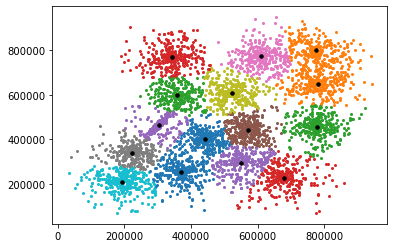

In [9]:
%time centroids, assigns, min_loss, avg_loss = kmeanspp(data, reps=100)
print(f"Avg loss: {avg_loss}")
print(f"Min loss: {min_loss}")
plot_clusters(data, assigns, centroids)

CPU times: user 6.34 s, sys: 356 ms, total: 6.69 s
Wall time: 26.6 s


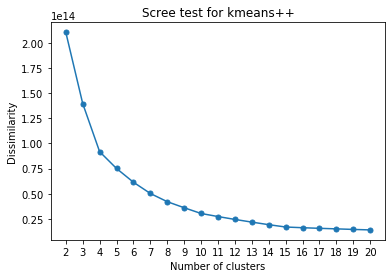

In [10]:
%%time
# performing scree test for kmeans++
losses = []
for i in range(2,21):
    *_, min_loss, avg_loss = kmeanspp(data, n_clusters=i, reps=100)
    losses.append(min_loss)
    
plt.title("Scree test for kmeans++")
plt.ylabel("Dissimilarity")
plt.xlabel("Number of clusters")
plt.xticks(range(2,21))
plt.plot(range(2,21), losses, marker='o', markersize=5)

## Exercise 2: fuzzy c-means

In [11]:
def update_assigns_fuzzy(data, centroids):
    squares = np.sum(np.square(np.tile(centroids, \
                (data.shape[0],1,1)) - data.reshape((data.shape[0],1,data.shape[1]))), axis=2)
    div_num = np.tile(squares.reshape((data.shape[0], centroids.shape[0], 1)), (1, 1, centroids.shape[0]))
    div_den = np.tile(squares.reshape((data.shape[0], 1, centroids.shape[0])), (1, centroids.shape[0], 1))
    rat_den = np.sum(np.divide(div_num, div_den), axis=2)
    return np.divide(np.ones(shape=(data.shape[0], centroids.shape[0])), rat_den)

In [12]:
def update_centroids_fuzzy(data, assign_probs):
    fact_1 = np.tile(data.reshape((data.shape[0], 1, data.shape[1])), (1, assign_probs.shape[1], 1))
    fact_2 = np.square(assign_probs).reshape((data.shape[0], assign_probs.shape[1], 1))
    num = np.sum(np.multiply(fact_1, fact_2), axis=0)
    den = np.sum(fact_2, axis=0)
    return np.divide(num, den)

In [13]:
def compute_loss_fuzzy(data, assign_probs, centroids):
    fact_1 = np.sum(np.square(np.tile(centroids, \
                (data.shape[0],1,1)) - data.reshape((data.shape[0],1,data.shape[1]))), axis=2)
    fact_2 = np.square(assign_probs)
    return np.sum(np.multiply(fact_1, fact_2))

In [14]:
def init_assign_probs(n_points, n_clusters):
    raw_mat = np.random.uniform(0.0,1.0,size=(n_points, n_clusters))
    return np.divide(raw_mat, np.sum(raw_mat, axis=1).reshape((n_points, 1)))

In [15]:
def _fuzzycmeans(data, n_clusters, tolerance=1.0e-8):
    centroids = kmpp_init(data, n_clusters) + [1,1]             # init clusters with k-means++
    # the +[1,1] is needed, otherwise in the first update of the
    # assign_probs the function fails due to zero division err 
    assign_probs = init_assign_probs(data.shape[0], n_clusters) # init assign_probs randomly
    changed = True; rep=0
    while(changed and rep<100):
        new_probs = update_assigns_fuzzy(data, centroids)
        changed = True if np.linalg.norm(new_probs - assign_probs) > tolerance else False
        centroids = update_centroids_fuzzy(data, new_probs) if changed else centroids
        assign_probs = new_probs if changed else assign_probs
        rep += 1
    loss = compute_loss_fuzzy(data, assign_probs, centroids)
    return centroids, assign_probs, loss

def fuzzycmeans(data, n_clusters=15, reps=10):  
    _results = Parallel(n_jobs=-1)(delayed(_fuzzycmeans)(data, n_clusters) for i in range(reps))
    _losses = [_results[i][2] for i in range(reps)]
    _avg = np.mean(_losses); 
    _best = _results[np.argmin(_losses)]
    return _best[0], _best[1], _best[2], _avg

CPU times: user 47.2 ms, sys: 16.5 ms, total: 63.8 ms
Wall time: 3.66 s
Avg loss: 8316364285146.635
Min loss: 7988108819322.486


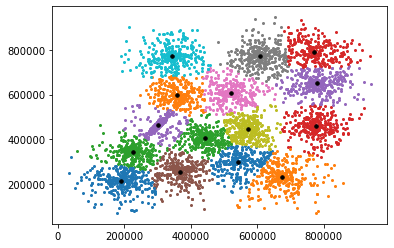

In [16]:
%time centroids, probs, min_loss, avg_loss = fuzzycmeans(data, 15)
print(f"Avg loss: {avg_loss}")
print(f"Min loss: {min_loss}")
plot_clusters(data, np.argmax(probs, axis=1), centroids)

CPU times: user 3.29 s, sys: 871 ms, total: 4.16 s
Wall time: 2min 26s


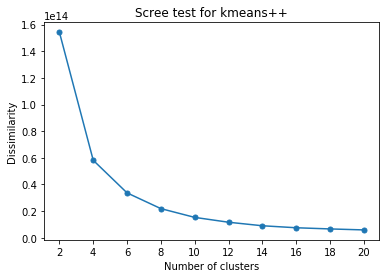

In [17]:
%%time
# performing scree test for fuzzy c-means
losses = []
for i in range(2,21,2): # takes too long otherwise
    *_, min_loss, avg_loss = fuzzycmeans(data, n_clusters=i, reps=50)
    losses.append(min_loss)
    
plt.title("Scree test for kmeans++")
plt.ylabel("Dissimilarity")
plt.xlabel("Number of clusters")
plt.xticks(range(2,21,2))
plt.plot(range(2,21,2), losses, marker='o', markersize=5)